# Week 4 Day 1 – Unsupervised Learning: Clustering + PCA

## Learning objectives
- Distinguish supervised and unsupervised learning
- Apply K-Means and DBSCAN clustering
- Choose clustering parameters using elbow, silhouette, and inspection
- Use PCA to visualize clusters in 2D
- Combine cluster labels with supervised models

## Section 1 — Introduction to Unsupervised Learning

**Supervised learning** uses a target variable (labels). The model learns to predict that target.

**Unsupervised learning** has no target variable. We look for hidden structure in the data.

**Clustering** groups similar observations together. There are no predefined labels — we must **interpret** what each cluster means in business or domain language.

> **Why interpretation matters:** A cluster number (0, 1, 2) is not useful by itself. We must describe each group (for example: high spenders, occasional visitors).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

%matplotlib inline
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

### Shared path helper

In [2]:
from pathlib import Path

def find_repo_root():
    cwd = Path.cwd().resolve()
    for candidate in [cwd] + list(cwd.parents):
        if (candidate / "requirements.txt").exists() and (candidate / "data").exists():
            return candidate
    return cwd

REPO_ROOT = find_repo_root()
DATA_DIR = REPO_ROOT / "data" / "week4"
FIGURES_DIR = REPO_ROOT / "Week_04_Unsupervised_Learning_Time_Series_and_Reporting" / "figures"
DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

CUSTOMER_CSV = DATA_DIR / "week4_customer_segmentation.csv"
AIRPASSENGERS_CSV = DATA_DIR / "week4_air_passengers.csv"


## Section 2 — Generate or Load Example Dataset

We start with `make_blobs` to see clear groups, then build a realistic **customer segmentation** table (income, spending score, visit frequency, age).

In [3]:
def create_customer_dataset(n_rows=400, seed=42):
    rng = np.random.default_rng(seed)
    centers = np.array([
        [55_000, 85, 12, 34],
        [32_000, 35, 4, 52],
        [78_000, 55, 8, 41],
    ])
    labels_true = rng.choice([0, 1, 2], size=n_rows, p=[0.35, 0.35, 0.30])
    rows = []
    for lab in labels_true:
        c = centers[lab]
        rows.append([
            rng.normal(c[0], 8_000),
            np.clip(rng.normal(c[1], 12), 1, 100),
            np.clip(rng.normal(c[2], 2), 1, 20),
            np.clip(rng.normal(c[3], 8), 18, 75),
        ])
    arr = np.array(rows)
    df = pd.DataFrame(arr, columns=['annual_income', 'spending_score', 'visit_frequency', 'age'])
    df = df.round({'annual_income': 0, 'spending_score': 1, 'visit_frequency': 1, 'age': 1})
    return df

if CUSTOMER_CSV.exists():
    customers = pd.read_csv(CUSTOMER_CSV)
else:
    customers = create_customer_dataset()
    customers.to_csv(CUSTOMER_CSV, index=False)
    print('Saved dataset to:', CUSTOMER_CSV)

display(customers.head())
print('\nShape:', customers.shape)
display(customers.describe().round(2))
print('\nMissing values:')
print(customers.isna().sum())

,annual_income,spending_score,visit_frequency,age
0,81517.0,61.3,8.6,29.7
1,13519.0,35.7,3.1,55.7
2,83616.0,56.7,9.5,42.8
3,36241.0,26.5,3.6,53.6
4,61564.0,80.3,13.0,31.9



Shape: (400, 4)


,annual_income,spending_score,visit_frequency,age
count,400.00,400.00,400.00,400.00
mean,52523.95,57.50,7.83,42.32
std,20456.48,24.03,3.93,11.01
min,10786.00,1.00,1.00,18.00
25%,34634.50,37.05,4.47,34.68
50%,52694.00,56.80,7.90,42.50
75%,69093.25,77.75,11.10,49.80
max,103431.00,100.00,16.80,71.00



Missing values:
annual_income      0
spending_score     0
visit_frequency    0
age                0
dtype: int64


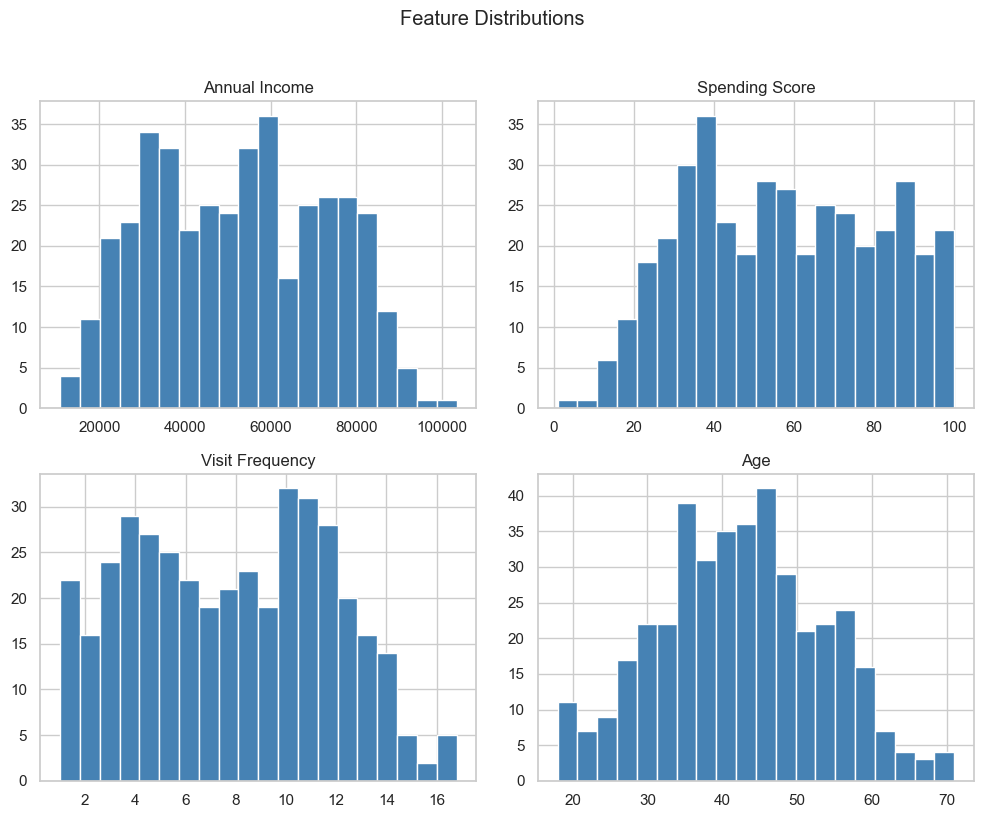

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
cols = ['annual_income', 'spending_score', 'visit_frequency', 'age']
for ax, col in zip(axes.ravel(), cols):
    ax.hist(customers[col], bins=20, color='steelblue', edgecolor='white')
    ax.set_title(col.replace('_', ' ').title())
plt.suptitle('Feature Distributions', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'day1_feature_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

## Section 3 — Preprocessing for Clustering

Distance-based algorithms (K-Means, DBSCAN) compare feature scales. If income is in thousands and spending score is 1–100, income dominates distance. **StandardScaler** centers each feature to mean 0 and unit variance.

In [5]:
feature_cols = ['annual_income', 'spending_score', 'visit_frequency', 'age']
X = customers[feature_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)
display(X_scaled_df.describe().round(2))

,annual_income,spending_score,visit_frequency,age
count,400.00,400.00,400.00,400.00
mean,0.00,0.00,0.00,0.00
std,1.00,1.00,1.00,1.00
min,-2.04,-2.35,-1.74,-2.21
25%,-0.88,-0.85,-0.85,-0.70
50%,0.01,-0.03,0.02,0.02
75%,0.81,0.84,0.83,0.68
max,2.49,1.77,2.28,2.61


/var/folders/w0/2jgnn0bx27b_jyy4mrm45cxm0000gn/T/ipykernel_50783/3918188909.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([customers[c] for c in feature_cols], labels=feature_cols)
/var/folders/w0/2jgnn0bx27b_jyy4mrm45cxm0000gn/T/ipykernel_50783/3918188909.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([X_scaled_df[c] for c in feature_cols], labels=feature_cols)


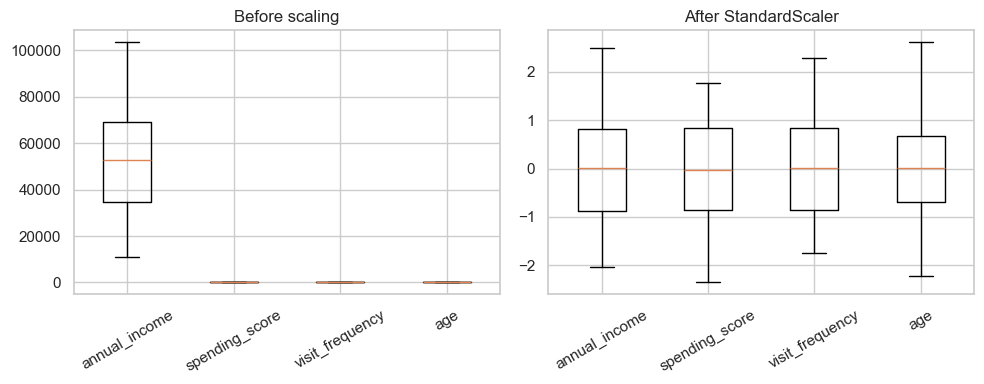

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].boxplot([customers[c] for c in feature_cols], labels=feature_cols)
axes[0].set_title('Before scaling')
axes[0].tick_params(axis='x', rotation=30)
axes[1].boxplot([X_scaled_df[c] for c in feature_cols], labels=feature_cols)
axes[1].set_title('After StandardScaler')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

## Section 4 — K-Means Clustering

K-Means partitions data into **K** groups by minimizing within-cluster distance (inertia / SSE).

- Choose **K** (number of clusters)
- Initialize centroids
- Assign points to nearest centroid
- Update centroids as cluster means
- Repeat until stable

In [7]:
k_values = range(2, 9)
inertias = []
sil_scores = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

param_df = pd.DataFrame({'K': list(k_values), 'inertia': inertias, 'silhouette': sil_scores})
display(param_df.round(3))

,K,inertia,silhouette
0,2,739.480,0.479
1,3,476.722,0.446
2,4,415.552,0.360
3,5,366.316,0.292
4,6,330.358,0.252
5,7,314.078,0.234
6,8,298.395,0.201


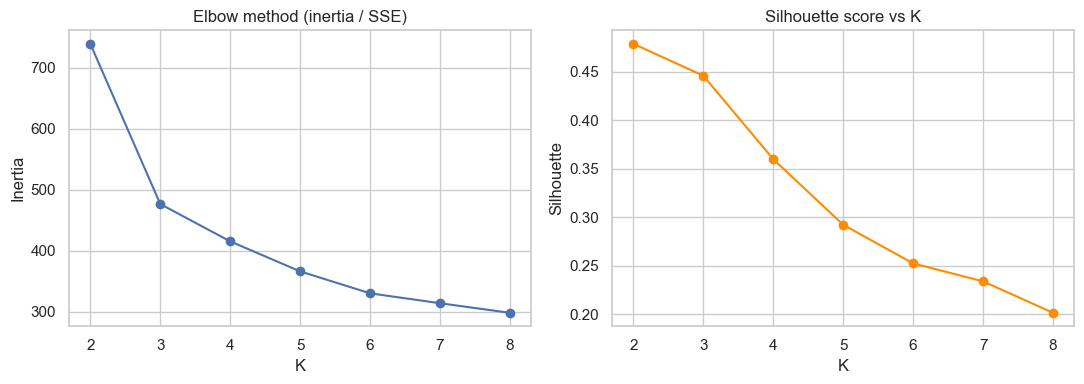

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(param_df['K'], param_df['inertia'], marker='o')
axes[0].set_title('Elbow method (inertia / SSE)')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertia')
axes[1].plot(param_df['K'], param_df['silhouette'], marker='o', color='darkorange')
axes[1].set_title('Silhouette score vs K')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'day1_kmeans_parameter_selection.png', dpi=120, bbox_inches='tight')
plt.show()

In [9]:
best_k = int(param_df.sort_values('silhouette', ascending=False).iloc[0]['K'])
print('Selected K (highest silhouette on this grid):', best_k)

kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
customers['kmeans_cluster'] = kmeans.fit_predict(X_scaled)
centers_original = scaler.inverse_transform(kmeans.cluster_centers_)
centers_df = pd.DataFrame(centers_original, columns=feature_cols)
centers_df.index.name = 'cluster'
display(centers_df.round(1))
print('Inertia:', round(kmeans.inertia_, 2))
print('Silhouette:', round(silhouette_score(X_scaled, customers['kmeans_cluster']), 3))

Selected K (highest silhouette on this grid): 2


,annual_income,spending_score,visit_frequency,age
cluster,,,,
0,64625.4,71.2,10.2,37.4
1,31696.3,33.9,3.7,50.9


Inertia: 739.48
Silhouette: 0.479


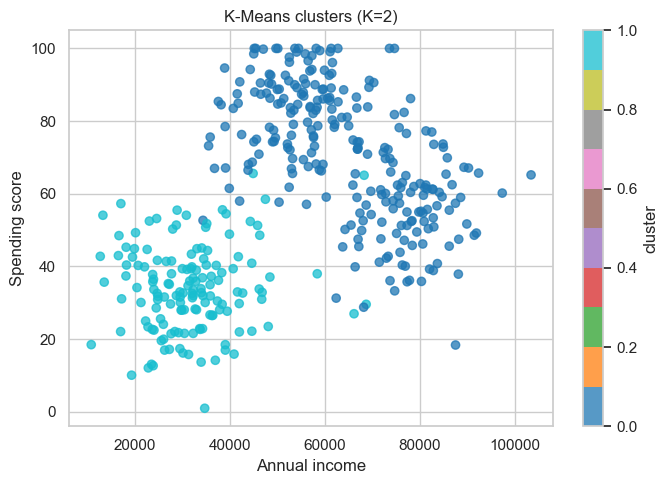

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(customers['annual_income'], customers['spending_score'],
                     c=customers['kmeans_cluster'], cmap='tab10', alpha=0.75)
ax.set_xlabel('Annual income'); ax.set_ylabel('Spending score')
ax.set_title(f'K-Means clusters (K={best_k})')
plt.colorbar(scatter, label='cluster')
plt.tight_layout(); plt.show()

### How to interpret K-Means clusters

Read cluster **centers** in original units:
- **Cluster 0 (example):** higher spending score and visit frequency → engaged shoppers
- **Cluster 1:** lower income and spending → budget-conscious segment
- **Cluster 2:** high income, moderate spending → potential upsell segment

Always validate interpretations with plots and domain knowledge.

## Section 5 — DBSCAN

DBSCAN groups dense regions and marks sparse points as **noise** (label −1).

- **eps:** neighborhood radius
- **min_samples:** points needed to form a dense region
- **Core points:** enough neighbors within eps
- **Border points:** near a core point
- **Noise:** neither core nor border

DBSCAN can find non-spherical clusters and outliers. It does **not** need K in advance.

In [14]:
def run_dbscan(eps, min_samples=5):
    model = DBSCAN(eps=eps, min_samples=min_samples)
    labels = model.fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = int((labels == -1).sum())
    sil = np.nan
    if n_clusters > 1:
        mask = labels != -1
        if mask.sum() > 1 and len(np.unique(labels[mask])) > 1:
            sil = silhouette_score(X_scaled[mask], labels[mask])
    return labels, n_clusters, n_noise, sil

eps_values = [0.35, 0.45, 0.55, 0.65, 0.75]
db_rows = []
for eps in eps_values:
    labels, n_cl, n_noise, sil = run_dbscan(eps)
    db_rows.append({'eps': eps, 'clusters': n_cl, 'noise_points': n_noise, 'silhouette': sil})
dbscan_summary = pd.DataFrame(db_rows)
display(dbscan_summary.round(3))

,eps,clusters,noise_points,silhouette
0,0.35,3,379,0.600
1,0.45,10,248,0.168
2,0.55,5,115,0.397
3,0.65,3,58,0.505
4,0.75,2,23,0.501


In [15]:
db_eps = 0.55
db_labels, n_db_clusters, n_db_noise, db_sil = run_dbscan(db_eps)
customers['dbscan_cluster'] = db_labels
print(f'DBSCAN (eps={db_eps}): clusters={n_db_clusters}, noise={n_db_noise}, silhouette={db_sil:.3f}')

DBSCAN (eps=0.55): clusters=5, noise=115, silhouette=0.397


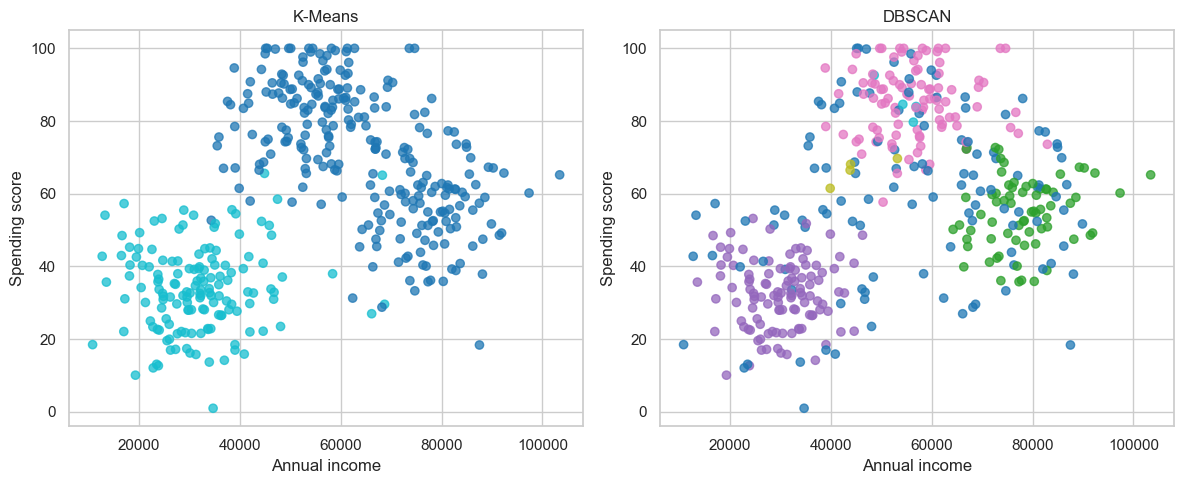

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(customers['annual_income'], customers['spending_score'],
                c=customers['kmeans_cluster'], cmap='tab10', alpha=0.75)
axes[0].set_title('K-Means')
axes[1].scatter(customers['annual_income'], customers['spending_score'],
                c=customers['dbscan_cluster'], cmap='tab10', alpha=0.75)
axes[1].set_title('DBSCAN')
for ax in axes:
    ax.set_xlabel('Annual income'); ax.set_ylabel('Spending score')
plt.tight_layout(); plt.show()

**DBSCAN does not require K, but it requires good `eps` and `min_samples`.** Too small `eps` → many noise points; too large → one giant cluster.

## Section 6 — Choosing Clustering Parameters

**K-Means:** elbow (inertia), silhouette, interpretability, domain knowledge.

**DBSCAN:** eps sensitivity, min_samples, noise percentage, visual inspection.

In [17]:
def summarize_dbscan_eps(eps_list, min_samples=5):
    rows = []
    for eps in eps_list:
        _, n_cl, n_noise, sil = run_dbscan(eps, min_samples=min_samples)
        rows.append({'eps': eps, 'clusters': n_cl, 'noise_points': n_noise, 'silhouette': sil})
    return pd.DataFrame(rows)

display(summarize_dbscan_eps([0.4, 0.5, 0.55, 0.6, 0.7]).round(3))

,eps,clusters,noise_points,silhouette
0,0.40,7,324,0.319
1,0.50,7,159,0.158
2,0.55,5,115,0.397
3,0.60,3,77,0.513
4,0.70,2,38,0.509


### Common mistakes / warnings
- Clustering on unscaled features when scales differ
- Choosing K only from the elbow when clusters overlap
- Treating DBSCAN noise (−1) as a normal segment
- Forgetting that cluster IDs are arbitrary (0 vs 2 can swap between runs)

## Section 7 — PCA for Cluster Visualization

**PCA (Principal Component Analysis)** finds directions of maximum variance.
- **PC1** and **PC2** are linear combinations of original features
- **Explained variance ratio** shows how much information each PC keeps

> **PCA does not create the clusters.** It helps us visualize them in 2D when we have many features.

In [18]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
customers['PC1'] = X_pca[:, 0]
customers['PC2'] = X_pca[:, 1]
print('Explained variance ratio:', np.round(pca.explained_variance_ratio_, 3))
print('Total variance explained (2 PCs):', round(pca.explained_variance_ratio_.sum(), 3))

Explained variance ratio: [0.646 0.174]
Total variance explained (2 PCs): 0.82


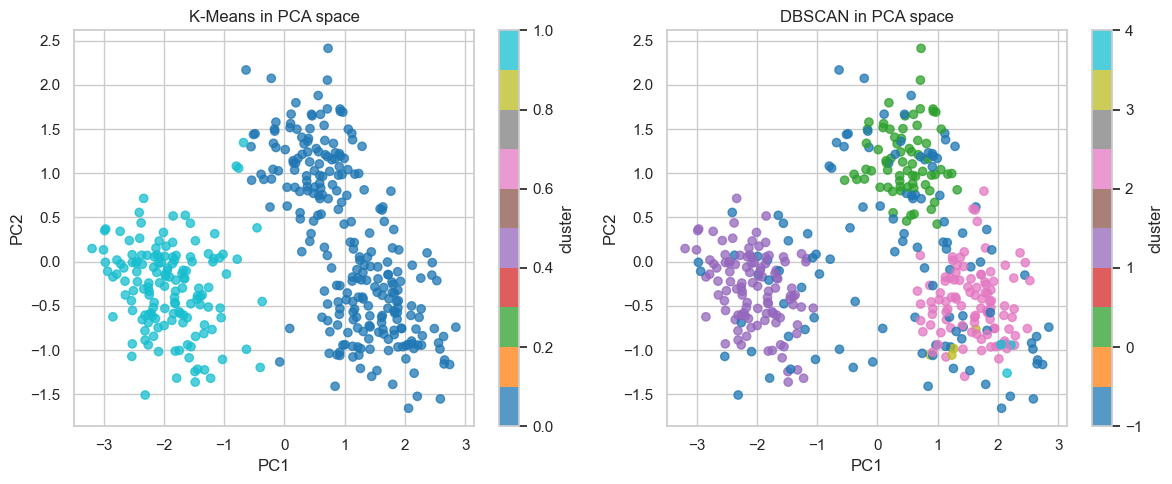

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col, title in zip(axes, ['kmeans_cluster', 'dbscan_cluster'], ['K-Means in PCA space', 'DBSCAN in PCA space']):
    sc = ax.scatter(customers['PC1'], customers['PC2'], c=customers[col], cmap='tab10', alpha=0.75)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_title(title)
    plt.colorbar(sc, ax=ax, label='cluster')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'day1_pca_cluster_plots.png', dpi=120, bbox_inches='tight')
plt.show()

## Section 8 — Combining Unsupervised and Supervised Workflows

Workflow:
1. Create a synthetic target (customer value)
2. Train regression **without** cluster label
3. Add cluster label as a feature and retrain
4. Compare MAE / RMSE / R²

In [20]:
rng = np.random.default_rng(RANDOM_STATE)
customers['customer_value'] = (
    0.02 * customers['annual_income']
    + 45 * customers['spending_score']
    + 80 * customers['visit_frequency']
    - 5 * customers['age']
    + rng.normal(0, 200, len(customers))
)

y = customers['customer_value']
X_base = customers[feature_cols]
X_with_cluster = customers[feature_cols + ['kmeans_cluster']]

Xb_train, Xb_test, y_train, y_test = train_test_split(X_base, y, test_size=0.2, random_state=RANDOM_STATE)
Xc_train, Xc_test, _, _ = train_test_split(X_with_cluster, y, test_size=0.2, random_state=RANDOM_STATE)

def reg_metrics(model, X_tr, X_te, y_tr, y_te, name):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    return {
        'Model': name,
        'MAE': mean_absolute_error(y_te, pred),
        'RMSE': np.sqrt(mean_squared_error(y_te, pred)),
        'R2': r2_score(y_te, pred),
    }

rows = [
    reg_metrics(LinearRegression(), Xb_train, Xb_test, y_train, y_test, 'Linear (no cluster)'),
    reg_metrics(LinearRegression(), Xc_train, Xc_test, y_train, y_test, 'Linear (+ cluster)'),
    reg_metrics(RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE), Xb_train, Xb_test, y_train, y_test, 'RF (no cluster)'),
    reg_metrics(RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE), Xc_train, Xc_test, y_train, y_test, 'RF (+ cluster)'),
]
supervised_cmp = pd.DataFrame(rows)
display(supervised_cmp.round(3))

,Model,MAE,RMSE,R2
0,Linear (no cluster),145.067,177.340,0.986
1,Linear (+ cluster),146.351,178.398,0.985
2,RF (no cluster),190.632,247.631,0.972
3,RF (+ cluster),221.456,280.565,0.964


In [21]:
# Optional: one model per cluster vs global model
global_rf = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)
global_rf.fit(X_base, y)
global_pred = global_rf.predict(X_base)
global_rmse = np.sqrt(mean_squared_error(y, global_pred))

per_cluster_preds = np.zeros(len(customers))
for cl in sorted(customers['kmeans_cluster'].unique()):
    mask = customers['kmeans_cluster'] == cl
    local = RandomForestRegressor(n_estimators=80, random_state=RANDOM_STATE)
    local.fit(X_base[mask], y[mask])
    per_cluster_preds[mask] = local.predict(X_base[mask])

local_rmse = np.sqrt(mean_squared_error(y, per_cluster_preds))
print('Global RF RMSE (in-sample demo):', round(global_rmse, 2))
print('Per-cluster RF RMSE (in-sample demo):', round(local_rmse, 2))

Global RF RMSE (in-sample demo): 90.02
Per-cluster RF RMSE (in-sample demo): 92.14


## Section 9 — Student Exercise

1. Choose **K** using elbow and silhouette.
2. Run K-Means with your chosen K.
3. Run DBSCAN with at least two `eps` values and compare noise/clusters.
4. Visualize clusters with PCA (PC1 vs PC2).
5. Interpret each cluster in simple language.
6. Write 3–5 sentences: which method worked better for this dataset and why?

### Reflection questions
- When would DBSCAN be preferable to K-Means?
- What business action could you take for one cluster?
- Did adding cluster labels improve supervised performance? Why might that happen?

## Mini summary
- Unsupervised learning discovers structure without labels.
- Scale features before distance-based clustering.
- K-Means needs K; DBSCAN needs eps and min_samples.
- PCA helps visualization but does not define clusters.
- Cluster labels can become features in supervised models.

## Final task checklist
- [ ] K chosen and justified
- [ ] K-Means and DBSCAN completed
- [ ] PCA plot saved
- [ ] Cluster interpretation written
- [ ] Supervised comparison attempted

In [19]:
print('Week 4 Day 1 Clustering + PCA completed successfully.')

Week 4 Day 1 Clustering + PCA completed successfully.
